# Example 2: Blazar simulation including external fields

### Single-zone external field blazar model by [Rodrigues et al, *Astron.Astrophys.* 681 (2024) A119](https://arxiv.org/abs/2307.13024).

### The parameters used are the best-fit values for PKS 0736+01 as reported in the above paper and on [this GitHub repository](https://github.com/xrod/lephad-blazars/).

### When using this model, please cite the above paper additionally to AM3.

In [1]:
import os
import sys
import numpy as np
import pickle as pickle
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
from astropy.constants import codata2010 as const
from matplotlib import pyplot as plt
import seaborn as sns

import am3

## 1. Initialize AM3 and set up preferred energy grids (run only once)

In [2]:
# Initialize 
am3 = am3.AM3()

# Adjust min photon energy, min neutrino energy, and max energy for all particles [eV].
# This allows us to optimize the performance depending on the needs of the specific science case
am3.update_energy_grid(1e-6, 1e3, 1e19)

## 2. Set AM3 switches and initialize kernels

This should be done **only once** every time you import the AM3 module.

Once you initialize AM3, the same kernel can be used for subsequent simulations. 

To inject different particle distributions, simply do `am3.clear_particle_densities()` and inject the new ones. This does not require a kernel recomputation.

To change the magnetic field, use `am3.set_mag_field(new_bfield)`. This triggers a kernel re-compuation.

In [3]:
%%time

# Manually define max proton and electron energy
am3.set_estimate_max_energies(0)

# Turn on for keeping track of the different SED components, for plotting purposes;
# turn off for efficiency.
am3.set_process_parse_sed(1)

# Hadronic processes on
am3.set_process_hadronic(1)

# Keep track of positrons and electrons separately
am3.set_process_merge_positrons_into_electrons(0)

# Escape (see documentation)
am3.set_process_escape(1)

# Expansion of radiation zone (see documentation). This one is stationary. 
am3.set_process_expansion(0)
am3.set_process_adiabatic_cooling(0)

# Electron synchrotron and synchrotron self-absorption
am3.set_process_electron_syn(1)
am3.set_process_ssa(1)

# Proton synchrotron - subdominant in this case, but may be relevant for B>~10 G
am3.set_process_proton_syn(1)

# Quantum synchrotron for pairs off by default.
# In AGN simulations this effect can typically be neglected, so turn off for efficiency
am3.set_process_quantum_syn(0)

# Inverse Compton by electrons and protons 
am3.set_process_electron_compton(1)
am3.set_process_proton_compton(1)

# Direct Compton turned off by default
am3.set_process_compton_photon_energy_loss(0)


# Synchrotron and inverse Compton by muons and pions - off by default.
# In AGN simulations this effect can typically be neglected, so turn off for efficiency
am3.set_process_muon_syn(0)
am3.set_process_pion_syn(0)
am3.set_process_muon_compton(0)
am3.set_process_pion_compton(0)

# Secondary particle decay
am3.set_process_pion_decay(1)
am3.set_process_muon_decay(1)

# Photon annihilation (gamma gamma -> e- e+)
am3.set_process_annihilation(1)
am3.set_optimize_annihilation_pair_emission(1) # optimization

# Bethe-Heitler pair production (p gamma -> p e+ e-)
am3.set_process_bethe_heitler(1)
am3.set_optimize_bethe_heitler_outgoing_pairs_grid(1)
am3.set_optimize_bethe_heitler_incoming_protons_min(1e12)
am3.set_optimize_bethe_heitler_target_photon_max(1e6)

# Photo-pion production (nucleon gamma -> nucleon pion)
am3.set_process_photopion(1)
am3.set_optimize_photopion_target_photon_grid(1)
am3.set_optimize_photopion_target_photon_max(1e6)

am3.set_profile_timing(1) # Used for profiling, as in the bottom plot. Turn off for efficiency.

# Initialize the kernels with the above switches
am3.init_kernels()

init. AM3 kernels:
CPU times: user 9.87 s, sys: 243 ms, total: 10.1 s
Wall time: 5.36 s
AM3 has the following switches (at step: 0)
estimate maximum energies: 0
parse sed components: 1
escape: 1
expansion: 0
adiabatic: 0
synchrotron:
  e+/-: 1  (em..: 1, cool.: 1)
  protons:1  (em..: 1, cool.: 1)
  pions:0  (em..: 1, cool.: 1)
  muons:0  (em..: 1, cool.: 1)
  syn-self-abs.:1
  e+/- quantum-syn.:0
inv. Compton:
  e+/-: 1  (em.. : 1, cool.: 1 (continuous))
  photon loss due to upscattering: 0
  protons:1  (em.. (step approx.): 1, no cooling)
  pions:0  (em.. (step approx.): 1, cont. cool.: 1)
  muons:0  (em.. (step approx.): 1, cont. cool.: 1)
pair prod. (gamma+gamma->e+e)1  (photon loss.: 1, e+/- source (feedback): 1(opt. 14-bin kernel))
'hadronic' processes (below): 1
 Pion decay: 1 Muon decay:1)
proton Bethe-Heitler: 1  (em..: 1, cool.: 1)
proton photo-pion: 1  (em..: 1, cool.: 1, photon loss: 1)
proton p-p: 1  (em..: 1 , cool.: 1)

AM3 params (comoving):
escape_timescale: 1e+06 s
  w

## 3. Set up and run the simulation

### Set magnetic field strength and escape timescale (light-crossing time of the region)

Additionally to the general escape timescale, the escape rate of each species can be individually adjusted.

For example, doing `am3.set_escape_fraction_charged_particles(0.01)` decreases the escape rate of charged particles by a factor 100.


In [5]:
## LOAD SOURE DATA FOR PLOTTING
DATAPATH = "/Users/xrodrigu/analysis/sin/"
with open(DATAPATH+"231106_sin_catalog.pkl", "rb") as f:
    CAT = pickle.load(f)
    
for s in CAT:
    if '0509' in s:     # TXS 0506+056
        source = CAT[s]
        sourcename = s
        break

data_x = source['data2311'][0] * 1
data_y = source['data2311'][1] * 1
data_errlo = source['data2311'][2] * 1
data_errup = source['data2311'][3] * 1
detections = source['data2311'][4]
is_uplim = (~detections) + (data_x < (300e9))
ev_to_hz = u.eV.to(u.J)/const.h.value
data_x /= ev_to_hz
data_err = np.maximum(data_errlo,data_errup)

def bin_data(data_x, data_y, data_err, is_uplim, eps=0.4):
    
    x = np.log10(data_x[~is_uplim])
    bins = np.arange(np.min(x) - eps/2, np.max(x) + eps, eps)
    dig = np.digitize(x,bins)-1

    
    binned_x = np.array([np.mean(np.log10(data_x[~is_uplim])[(x >= bins[i]) * (x < bins[i] + eps)]) 
                         for i in set(dig)])
    binned_y = np.array([np.mean(np.log10(data_y[~is_uplim])[(x >= bins[i]) * (x < bins[i] + eps)]) 
                         for i in set(dig)])
    binned_e = np.log10(np.array([np.max(((data_err[~is_uplim]+data_y[~is_uplim])/data_y[~is_uplim])[(x >= bins[i]) * (x < bins[i] + eps)]) 
                                  for i in set(dig)]))
    binned_spread = np.array([np.ptp(np.log10(data_y[~is_uplim])[(x >= bins[i]) * (x < bins[i] + eps)]) 
                              for i in set(dig)])
    binned_spread *=0.5
    binned_spread = np.maximum(np.full(binned_spread.size,0.1), binned_spread)
    binned_err = np.maximum(binned_spread,binned_e)

    errrange = is_uplim * (data_x < 1e-3)
    binned_x = np.concatenate([binned_x,np.log10(data_x[errrange])])
    binned_y = np.concatenate([binned_y,np.log10(data_y[errrange])])
    binned_err = np.concatenate([binned_err,np.log10((data_err[errrange]+data_y[errrange])/data_y[errrange])])
    
    binned_isuplim = np.full(binned_err.size, False)
    binned_isuplim[binned_e.size:] += True
    
    srt = np.argsort(binned_x[np.isfinite(binned_x)])
    return binned_x[srt], binned_y[srt], binned_err[srt], binned_isuplim[srt]

binned_x, binned_y, binned_err, binned_isuplim = bin_data(data_x, data_y, data_err, is_uplim)

idel = []
if sourcename == '4FGLJ0649.5-3139':
    idel = np.where((binned_x > -2.5) * (~binned_isuplim))[0][:1]

binned_x, binned_y, binned_err, binned_isuplim = (np.delete(binned_x,idel), 
                                                    np.delete(binned_y,idel), 
                                                    np.delete(binned_err,idel), 
                                                    np.delete(binned_isuplim,idel))


In [ ]:
# Set homogeneous magnetic field strength
am3.set_mag_field(1.6)

# Set escape time scale (subject to escape switch - in this case escape is on)
am3.set_escape_timescale(10**16.4 / const.c.cgs.value) # 4.62e16 cm == Size of the region

# This timescale would control adiabatic cooling losses as well as the reduction in particle density 
# due to the expansion of the region.
# In this example, both processes are turned off because we simulate a stationary region, so there is
# no need to define it. 
# am3.set_expansion_timescale(4.62e+16 / const.c.cgs.value) 

# This simulation is optically thin, so below we set a time step == escape_timescale / 100.
# For more optically thick environments, it may be necessary to decrease the solver time step 
# due to the numerical hardness of the equations, which may lead to numerically imprecise results.
# As a rule of thumb, we want to look at the fastest process rates at the relevant particle energies.
am3.set_solver_time_step(1e-1 * am3.get_escape_timescale()) 


# Define BLR and torus parameters

DISK_LUM = source['thermal_and_syn_fits']['disk'][2] * u.erg/u.s
black_hole_mass = 3e8 # [solar mass units]
blr_radius = 1e17*(DISK_LUM.value/1e45)**0.5 # [cm]
torus_radius = 2.5e18*(DISK_LUM.value/1e45)**0.5 # [cm] # [cm]

lorentz =    14.8 # Jet bulk Lorentz factor
                  # (impacts the relativistic boosting of external fields)
rdiss =      blr_radius * 2.4 # Dissipation radius in cm (cf Rodrigues+2023 Fig.2)
                      # this value, as well as the values in Tab. B1, 

torus_temperature = 1000 * u.K
blr_covering, torus_covering = 0.1, 0.1


### Define accelerated electron spectrum

This is an example of the most generic way to inject any user-defined electron spectrum. 

For the specfic case of simple or broken power law injection, the same can be achieved with the template function provided in AM3. For example,

```
volume = 4./3 * np.pi * (am3.get_escape_timescale() * const.c.cgs.value) ** 3
am3.set_powerlaw_injection_parameters_electrons(volume, elum, elec_emin, elec_emin, elec_emax, eindex, eindex, 1.0)
```

In [ ]:
# Create spectrum, in this case a simple power law.
# The same can also be achieved using the template powerlaw function:
# am3.set_electron_powerlaw_injection_parameters_parameters((elum, elec_emin, elec_emin, elec_emax, eindex, eindex, 1.0))

elec_emin =  100 * (const.m_e * const.c ** 2).to(u.eV).value # eV
elec_emax =  1.20e4 * (const.m_e * const.c ** 2).to(u.eV).value # eV
eindex =     1.3
elum =       10**41.9 # erg/s


egrid = am3.get_egrid_lep()
epowerlaw = (egrid ** (2 - eindex) 
                * (egrid >= elec_emin)
                * np.exp(- egrid / elec_emax)
            )
# Integrate spectrum in erg/s
etrapz = np.trapezoid(epowerlaw / egrid, egrid)

# Normalize it to the desired electron lumiosity
enormalized = epowerlaw * elum / etrapz # erg/s

# Convert it to an energy density injection rate
volume = 4/3 * np.pi * (am3.get_escape_timescale() * const.c.cgs.value) ** 3
enormalized /= volume # erg/cm3/s

# And finally to a particle density injection rate
enormalized /= egrid * u.eV.to(u.erg) # cm-3.s-1


### Define accelerated proton spectrum

This is an example of the most generic way to inject any user-defined proton spectrum. 

For the specfic case of simple or broken power law injection, the same can be achieved with the template function provided in AM3:

```
volume = 4./3 * np.pi * (am3.get_escape_timescale() * const.c.cgs.value) ** 3
am3.set_powerlaw_injection_parameters_protons(volume, plum, proton_emin, proton_emin, proton_emax, pindex, pindex, 1.0)
```

In [ ]:
# Create spectrum, in this case a simple power law.
# The same can be achieved using the template powerlaw function:
# io.set_proton_powerlaw_injection_parameters_parameters((plum, proton_emin, proton_emin, proton_emax, pindex, pindex, 1.0))

proton_emin =  1e2 * (const.m_p * const.c ** 2).to(u.eV).value # eV 
proton_emax =  10**8.6 * (const.m_p * const.c ** 2).to(u.eV).value
pindex =     1.0
plum =       10**43.9#44.6 # erg/s

pgrid = am3.get_egrid_had()
ppowerlaw = (pgrid ** (2 - pindex)
                * (pgrid >= proton_emin)
                * np.exp(- pgrid / proton_emax)
            )
                   
# Integrate spectrum in erg/s
ptrapz = np.trapezoid(ppowerlaw / pgrid, pgrid)
      
# Normalize it to the desired proton lumiosity
pnormalized = ppowerlaw * plum / ptrapz # erg/s
           
# Convert it to an energy density injection rate
volume = 4/3 * np.pi * (am3.get_escape_timescale() * const.c.cgs.value) ** 3
pnormalized /= volume # erg/cm3/s
    
# And finally to a particle density injection rate
pnormalized /= pgrid * u.eV.to(u.erg) # cm-3.s-1

### Define external photon spectrum

In this case we consider three components (see Fig. 2 of [Rodrigues+ 2023](https://arxiv.org/abs/2307.13024)):
    
- Broad lines from hydrogen and helium Lymann alpha emission
- Fraction of the thermal disk emission scattered in the BLR
  (following a multi-temperature Shakura-Sunaev spectrum)
- Infrared emission from a dust torus 
  (following a simple black-body spectrum)

Below we define arrays with the spectral shapes of these different components, normalize them to the disk luminosity including the respective covering factors, boost them into the jet rest frame, add them up into a single array, and finally inject this in the simulation as external photons.

In [238]:
def PlanckDistribution(earr, temperature, lum):
    '''
    Thermal Distribution (unnormalized)

    return: E^2dN/dE [a.u.]
    par earr (array): photon energy [eV]
    par temperature [K]
    par lum: total luminosity [erg/s]
    '''
    lgr = earr / temperature / const.k_B.to(u.eV/u.K)
    exparr = np.exp(lgr) - 1
    ednde = earr ** 4 / exparr
    integ = np.trapezoid(ednde / earr, earr)
    return ednde * lum / integ


def Schwarzschild(m_bh):
    '''Schwarzschild radius [cm]
    
    m_bh: black hole mass [m_solar]
    '''
    rad = (2 * const.G * m_bh * 1.989e30*u.kg 
           / const.c ** 2)
    return rad.to(u.cm)


def DiskTemperature(rad, lumdisk, m_bh, eta=0.08):
    '''Radius-dependent disk temperature [K]
    '''
    sb = const.sigma_sb.to(u.erg/u.s/
                           u.K**4/u.cm**2)
    rsch = Schwarzschild(m_bh)
    
    term1 = 3 * rsch * lumdisk / (16 * np.pi * eta 
                                  * sb * rad ** 3)
    term2 = 1 - (3 * rsch / rad) ** 0.5
    return (term1 * term2) ** 0.25
 

def ShakuraFlux(earr, lumdisk, m_bh, thetaobs=3.0, eta=0.08):
    '''Disk spectral flux in observer's frame [erg/cm2/s]
    
    earr (array): photon energies [eV]
    lumdisk: [erg/s]
    m_bh: black hole mass / m_solar
    thetaobs: angle btw. LOS and disk rotation axis (deg)
    '''
    kB = const.k_B.to(u.eV/u.K)
    c0 = const.c.cgs
    hplanck = const.h.to(u.eV*u.s)
#     dlum = cosmo.luminosity_distance(z).to(u.cm)
    rsch = Schwarzschild(m_bh)
    rin = 3 * rsch
    rout = 300 * rsch
    radarr = np.linspace(rin, rout, 50)
    
    frac = (4 * np.pi) ** 2 * hplanck * np.cos(thetaobs*np.pi/180) / c0 ** 2
    nuarr = earr / hplanck       # convert x-axis to obs frame
    en2d = earr[:,np.newaxis]    # convert x-axis to obs frame
    rad2d = radarr[np.newaxis,:]
    temp2d = DiskTemperature(rad2d,lumdisk,m_bh,eta) # K
    
    integrand = rad2d / (np.exp(en2d/temp2d/kB) - 1)
    integral = np.trapezoid(integrand, radarr, axis=1)
    Fnu = (nuarr ** 3 * frac * integral).to(u.erg)
    return nuarr * Fnu

def BroadLine(earr, center, width, lum):
    '''
    Broad line spectrum, normalized to `lum` 

    return: E^2dN/dE [a.u.]
    par earr (array): photon energies (eV)
    par center: line energy [eV]
    par width: line width (eV)
    par lum: line luminosity [erg/s]
    '''
    ednde = np.exp(-0.5 
                   * (earr - center) ** 2 
                   / width ** 2
                  )
#     ednde[ednde < 1e-100] = 0.
    integ = np.trapezoid(ednde/earr, earr)
    ednde *= lum / integ
    return ednde

def get_BLR_density_scaling(R_zone, R_diss, lorentz):
    '''Scaling of the photon density seen in the jet frame 
    with the dissipation radius, according to Eq. 20 of 
    Ghisellini+Tavecchio 0902.0793
    '''

    def scaling_for_large_R_diss(R_diss, R_zone, lorentz):
        beta = (1 - 1. / lorentz ** 2) ** 0.5
        mu1 = (1 + (R_zone / R_diss) ** 2) ** -.5
        mu2 = (1 - (R_zone / R_diss) ** 2) ** .5
        f_mu = (2 * (1 - beta * mu1) ** 3
                - (1 - beta * mu2) ** 3
                - (1 - beta) ** 3)
        return f_mu / 3. / beta

    f0 = 17. / 12
    
    if R_diss <= R_zone:
        scaling = f0
        
    elif R_diss >= 3 * R_zone:
        scaling = scaling_for_large_R_diss(
            R_diss,
            R_zone,
            lorentz)
        
    elif R_zone < R_diss < 3 * R_zone:
        # Power-law interpolation
        f_3R = scaling_for_large_R_diss(
            3 * R_zone, 
            R_zone,
            lorentz
        )
        scaling = 10 **(
            (np.log10(f_3R) - np.log10(f0))
            / (np.log10(3 * R_zone) - np.log10(R_zone))
            * (np.log10(R_diss) - np.log10(R_zone))
        )
        
    return scaling
     
def tangential_angle(R_BLR, R_diss):
    '''Calculate the characteristic angle of the radiaiton,
        which is the tangential angle. This is where the dominant
        contribution comes from because it has the highest doppler
        boost, as well as for geometric reasons.
    '''
    csi = np.arcsin(R_BLR/R_diss)
    return csi

def calc_doppler(lorentz, R_BLR, R_diss):
    '''Calculate relative Doppler factor between blob and BLR.
        The blob has bulk factor `lorentz` and distance to the black hole 
        given by `R_diss` [cm]. The BLR has radius `R_BLR` [cm].
    '''
    if R_diss <= R_BLR:
        return lorentz
         
    csi = tangential_angle(R_BLR, R_diss)
    beta = (1 - 1. / lorentz ** 2) ** 0.5
    doppler = lorentz * (1 - beta * np.cos(csi))
    return doppler

def convert_lum_to_density_in_jet(R_diss, lorentz, R_BLR):
        ''' Convert external field luminosity in the rest frame of the 
        black hole in [erg/s] into energy density in the comoving frame 
        of the jet blob in [GeV / cm^3]. R_BLR can represent the BLR radius
        or the dust torus radius. 

        This is an *approximation where the emission is considered to come 
        only from the tangential direction*. See Fig. 1 of Ghisellini and
        Tavecchio 2009 (arXiv:0902.0793) 

        return: conversion factor [GeV erg^-1 s cm^-3]
        '''      

        f1 = (lorentz ** 2 # In a previous version of the notebook,
                           # this line read (Doppler factor) ** 2.
                           # This is the correct expression.
                / (4.
                    * np.pi 
                    * R_BLR ** 2 
                    * const.c.cgs.value)
                * u.erg.to('GeV'))
                
        f2 = get_BLR_density_scaling(R_BLR, R_diss, lorentz)
        factor =  f1 * f2 
        
        return factor




blr_doppler = calc_doppler(lorentz, blr_radius, rdiss)
torus_doppler = calc_doppler(lorentz,torus_radius,rdiss)

# AM3 photon grid
egrid_jetframe = am3.get_egrid_photons() * u.eV 

# Set up array for adding up external fields
external_photons = np.zeros(egrid_jetframe.size) * u.GeV / u.cm**3

# Scattered thermal disk emission
disky = ShakuraFlux(egrid_jetframe / blr_doppler, 
                    DISK_LUM, 
                    black_hole_mass, 
                    3.0) # erg/s, black hole frame

# Broad line emission
hybl = BroadLine(egrid_jetframe / blr_doppler, 
                    10.2*u.eV, 10.2*u.eV/20, 
                    DISK_LUM * blr_covering) # H Ly alpha [erg/s]
hebl = BroadLine(egrid_jetframe / blr_doppler, 
                    40.8*u.eV, 40.8*u.eV/20, 
                    DISK_LUM * blr_covering * 0.5) # He Ly alpha [erg/s]
# Convert BLR components to jet frame
blr_to_jet = convert_lum_to_density_in_jet(rdiss,lorentz,blr_radius) # erg/s -> GeV/cm3 
blr_to_jet *= u.GeV / u.cm ** 3 / (u.erg / u.s) # give it units

blr_pho = (disky * 0.01 + hybl + hebl) * blr_to_jet # GeV/cm3

external_photons += blr_pho

# Dust torus
torusy = PlanckDistribution(egrid_jetframe / torus_doppler,
                            torus_temperature,
                            DISK_LUM * torus_covering) # [erg/s]  
# Convert torus emission to jet frame
tor_to_jet = convert_lum_to_density_in_jet(rdiss,lorentz,torus_radius) # erg/s -> GeV/cm3 
tor_to_jet *= u.GeV / u.cm**3 / (u.erg/u.s)  # give it units
# Add torus to BLR components 
torus_pho = torusy * tor_to_jet
external_photons += torus_pho

# Convert summed up components from energy density to photon density in jet frame
external_photonspectrum = (external_photons / egrid_jetframe).to(u.cm ** -3).value # cm-3

# Convert photon density to density ijnjection rate
external_photonspectrum /= am3.get_escape_timescale() # cm-3.s-1





/opt/anaconda3/envs/am3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/am3/lib/python3.12/site-packages/astropy/units/quantity.py:659: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


### Inject electron, proton and photon arrays defined above into the simulation.

The next two cells can be re-run with the same kernel to simulate different particle distributions with the same magnetic field.

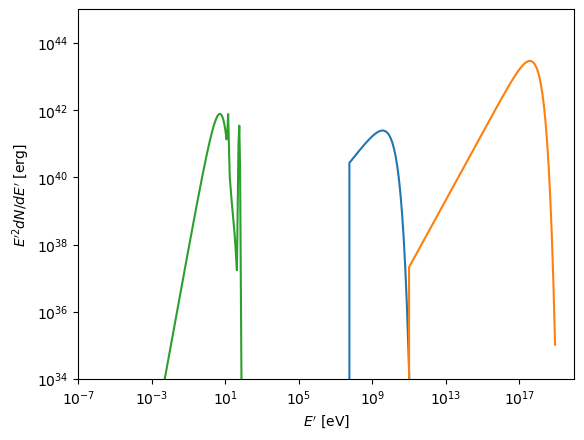

CPU times: user 86.9 ms, sys: 6.38 ms, total: 93.3 ms
Wall time: 94.3 ms


In [239]:
%%time
# Reset all particle arrays to zero
am3.clear_particle_densities()

# Inject cosmic rays and external photons in the simulation
am3.set_injection_rate_electrons(enormalized)
am3.set_injection_rate_protons(pnormalized)

am3.set_injection_rate_photons(external_photonspectrum)

# Start the system with correct initial external photon density
# (this should not strongly affect the steady-state result)
am3.set_current_densities_photons(external_photonspectrum * am3.get_escape_timescale())

saved_photons = am3.get_photons()

# Plot injection rates
density_injection_rate_to_luminosity = 4 * np.pi / 3 * am3.get_escape_timescale() ** 3 * const.c.cgs.value ** 3 * u.eV.to(u.erg) # eV/cm3-> erg/s
plt.loglog(am3.get_egrid_lep(), am3.get_injection_rate_electrons() * am3.get_egrid_lep() * density_injection_rate_to_luminosity)
plt.loglog(am3.get_egrid_had(), am3.get_injection_rate_protons() * am3.get_egrid_had() * density_injection_rate_to_luminosity)
plt.loglog(am3.get_egrid_photons(), am3.get_injection_rate_photons() * am3.get_egrid_photons() * density_injection_rate_to_luminosity)
plt.axis([1e-7,1e20,1e34,1e45])
plt.xlabel(r'$E^\prime$ [eV]')
plt.ylabel(r'$E^{\prime2} dN/dE^\prime$ [erg]')
plt.show()

### Run simulation

In [240]:
%%time

profiling = []

time = 0.
while time < 3 * am3.get_escape_timescale(): # Run up to 3x the light-crossing time a
    am3.evolve_step() # Evolve solver
    time += am3.get_solver_time_step() # Count time
    profiling.append(am3.get_profiled_times()) # Add computation times for profiling


CPU times: user 582 ms, sys: 15.4 ms, total: 597 ms
Wall time: 307 ms


## 4. Plot results

### Particle densities and interaction rates in the source rest frame

/var/folders/25/d230kxr90hj414fnx8hg1f_4000956/T/ipykernel_17803/1099422938.py:244: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=(0.5,0,1,1))


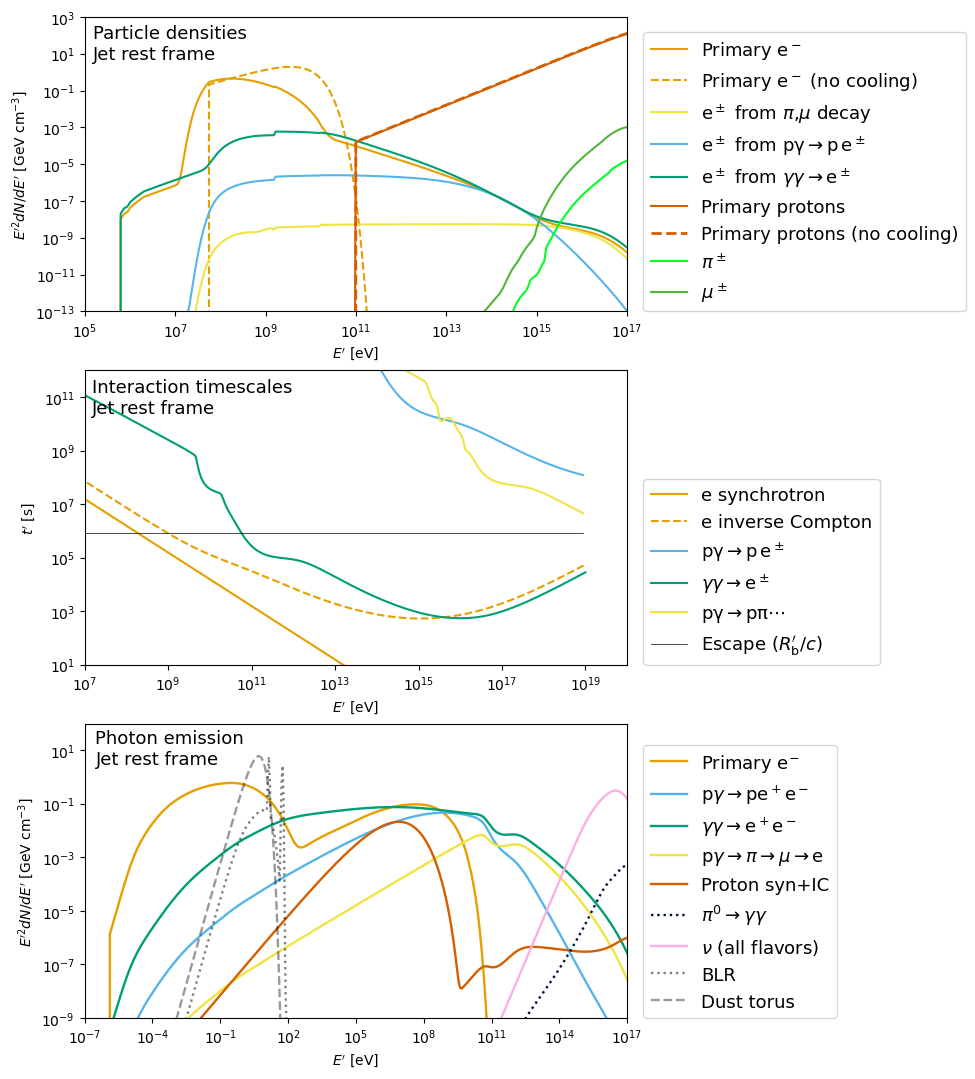

In [241]:
mycolors = np.array([np.array([230,159,  0.]),
                     np.array([ 86,180,233.]),
                     np.array([  0,158,115.]),
                     np.array([240,228, 66.]),
                     np.array([  0,114,178.]),
                     np.array([213, 94,  0.]),
                     np.array([201,121,176.])])
mycolors *= 1./255

fig, axs = plt.subplots(3, 1, figsize=(7, 13)) # , gridspec_kw={'width_ratios': [1,1]}

##############
## Particle densities
##############

ax1 = axs[0]
plt.sca(ax1)


egrid_ele = am3.get_egrid_lep()
egrid_had = am3.get_egrid_had()


ele_mass = (const.m_e * const.c ** 2).cgs.to(u.eV).value
pro_mass = (const.m_p * const.c ** 2).cgs.to(u.eV).value

colors = sns.color_palette("hsv", n_colors=10)
color_ele_primary = colors[-1]
color_ele_secondary = colors[-2]
color_pro = colors[5]

color_muon = sns.xkcd_rgb['leafy green']
color_pion = colors[-7]


plt.loglog(egrid_ele, 
           am3.get_electrons() * egrid_ele*u.eV.to(u.GeV),
           c=mycolors[0],
           label='Primary e$^-$')
plt.loglog(egrid_ele, 
           am3.get_injection_rate_electrons() * egrid_ele*u.eV.to(u.GeV) * am3.get_escape_timescale(), 
           c=mycolors[0], ls='--',
           label='Primary e$^-$ (no cooling)')
plt.loglog(egrid_ele, 
           am3.get_pairs_photopion() * egrid_ele * u.eV.to(u.GeV), 
           c=mycolors[3],
           label=r'e$^\pm$ from $\pi$,$\mu$ decay')

plt.loglog(egrid_ele, 
           am3.get_pairs_bethe_heitler() * egrid_ele * u.eV.to(u.GeV), 
           c=mycolors[1],
           label=r'e$^\pm$ from $\rm{p}\gamma\rightarrow \rm{p}\,\rm{e}^\pm$')


plt.loglog(egrid_ele, 
           am3.get_pairs_annihilation() * egrid_ele * u.eV.to(u.GeV), 
           c=mycolors[2],
           label=r'e$^\pm$ from $\gamma\gamma\rightarrow \rm{e}^\pm$')


plt.loglog(egrid_had, 
           am3.get_protons() * egrid_had*u.eV.to(u.GeV) ,
           c=mycolors[5],
           label='Primary protons')

plt.loglog(egrid_had, 
           am3.get_injection_rate_protons() * egrid_had*u.eV.to(u.GeV) * am3.get_escape_timescale(),
           c=mycolors[5], 
           ls='--',
           lw=2,
           label='Primary protons (no cooling)')

plt.loglog(egrid_had, 
           am3.get_pions() * egrid_had * u.eV.to(u.GeV), 
           c=color_pion, ls='-',
           label=r'$\pi^\pm$')


plt.loglog(egrid_had, 
           am3.get_muons() * egrid_had * u.eV.to(u.GeV), 
           c=color_muon, ls='-',
           label=r'$\mu^\pm$')

plt.annotate("Particle densities\nJet rest frame", 
             (1.5e5,4e2), 
             fontsize=13, 
             horizontalalignment='left',
             verticalalignment='top')

plt.legend(loc=(0,0),ncol=1,bbox_to_anchor=(1.03,0),fontsize=13)
plt.xlabel(r"$E^\prime$ [eV]")
plt.ylabel(r"$E^{\prime2} dN/dE^\prime$ [GeV cm$^{-3}$]")
plt.axis([1e5,1e17,1e-13,1e3])




##############
## Timescales
##############

ax2 = axs[1]
plt.sca(ax2)


egrid_ele = am3.get_egrid_lep()
egrid_pro = am3.get_egrid_had()
egrid_pho = am3.get_egrid_photons()

ele_mass = (const.m_e * const.c ** 2).cgs.to(u.eV).value
pro_mass = (const.m_p * const.c ** 2).cgs.to(u.eV).value

colors = sns.color_palette("hsv", n_colors=10)
color_ele_primary = colors[-1]
color_ele_secondary = colors[-2]
color_pro = colors[5]

color_muon = colors[-10]
color_pion = colors[-7]


plt.loglog(egrid_ele, 
           am3.get_t_pair_syn(),
           c=mycolors[0],
           label='e synchrotron')
plt.loglog(egrid_ele, 
           am3.get_t_pair_compton(), 
           c=mycolors[0], ls='--',
           label='e inverse Compton')

plt.loglog(egrid_had, 
           am3.get_t_proton_bethe_heitler(), 
           c=mycolors[1],
           label=r'$\rm{p}\gamma\rightarrow \rm{p}\,\rm{e}^\pm$')

plt.loglog(egrid_pho, 
           am3.get_t_photon_annihilation(),  
           c=mycolors[2],
           label=r'$\gamma\gamma\rightarrow \rm{e}^\pm$')

plt.loglog(egrid_had,
           am3.get_t_proton_photopion(), 
           c=mycolors[3],
           label=r'$\rm{p}\gamma\rightarrow \rm{p}\pi\cdots$')

plt.loglog([egrid_ele[0], egrid_had[-1]], 
           np.full(2, am3.get_escape_timescale()),
           c='k',
           lw=0.5,
           label=r'Escape ($R_\mathrm{b}^\prime/c$)')


plt.annotate("Interaction timescales\nJet rest frame", 
             (1.5e7,5e11), 
             fontsize=13,
             horizontalalignment='left',
             verticalalignment='top')

plt.legend(loc=(0,0),ncol=1,bbox_to_anchor=(1.03,0),fontsize=13)
plt.xlabel(r"$E^\prime$ [eV]")
plt.ylabel(r"$t^\prime$ [s]")
plt.axis([1e7,1e20,1e1,1e12])


##############
## Jet frame SED
##############

ax3 = axs[2]
plt.sca(ax3)


# Energy arrays in source frame
egrid_pho = am3.get_egrid_photons()
egrid_nu = am3.get_egrid_neutrinos()

# Get individual SED components

all_nu = am3.get_neutrinos() * egrid_nu * u.eV.to(u.GeV)
external_pho = am3.get_injection_rate_photons() * am3.get_escape_timescale() *  egrid_pho * u.eV.to(u.GeV)
injected = am3.get_photons_injected_electrons_syn_compton() * egrid_pho * u.eV.to(u.GeV)
annihil = am3.get_photons_annihilation_pairs_syn_compton() * egrid_pho * u.eV.to(u.GeV)
all_photons = am3.get_photons() * egrid_pho * u.eV.to(u.GeV)
bheitler = am3.get_photons_bethe_heitler_pairs_syn_compton() * egrid_pho * u.eV.to(u.GeV)
pgamma = am3.get_photons_photo_pion_pairs_syn_compton() * egrid_pho * u.eV.to(u.GeV)
pi0decay = am3.get_photons_pi0_decay() * egrid_pho * u.eV.to(u.GeV)
proton_syn_ic = am3.get_photons_protons_syn_compton() * egrid_pho * u.eV.to(u.GeV)


# Create plot



# Plot components
plt.loglog(egrid_pho, injected,
            c=mycolors[0],
            lw=1.7,
            label=r'Primary e$^{-}$')
plt.loglog(egrid_pho, bheitler,
            c=mycolors[1],
            lw=1.7,
            label=r'p$\gamma\rightarrow$pe$^+$e$^-$')

plt.loglog(egrid_pho, annihil,
            c=mycolors[2],
            lw=1.7,
            label=r'$\gamma\gamma\rightarrow$e$^+$e$^-$')
plt.loglog(egrid_pho, pgamma,
            c=mycolors[3],
            lw=1.7,
            label=r'p$\gamma\rightarrow\pi\rightarrow\mu\rightarrow$e')
plt.loglog(egrid_pho, proton_syn_ic,
            c=mycolors[5],
            lw=1.7,
            label='Proton syn+IC')
plt.loglog(egrid_pho, pi0decay,
            c=sns.xkcd_rgb['navy blue'], 
            ls=':',lw=1.7,
            label=r'$\pi^0\rightarrow\gamma\gamma$')

# Plot all-flavor neutrino spectrum
plt.loglog(egrid_nu, all_nu, label=r'$\nu$ (all flavors)',
           lw=1.7, color=sns.color_palette("colorblind",12)[6])


# Plot external photons
plt.loglog(egrid_pho, blr_pho, # obs frame, erg/cm2/s
           lw=1.7, c='k', ls=':',alpha=0.5,label=r'BLR')
plt.loglog(egrid_pho, torus_pho, # obs frame, erg/cm2/s
           lw=1.7, c='k', ls='--',alpha=0.4,label=r'Dust torus')

plt.xlabel(r"$E^\prime$ [eV]")
plt.ylabel(r"$E^{\prime2} dN/dE^\prime$ [GeV cm$^{-3}$]")
plt.axis([1e-7,1e17,1e-9,1e2])

plt.annotate("Photon emission\nJet rest frame", 
             (3e-7,6e1), 
             fontsize=13, 
             horizontalalignment='left',
             verticalalignment='top')

plt.legend(loc=(1.03,0), fontsize=13,frameon=1,ncol=1)

plt.tight_layout(rect=(0.5,0,1,1))
    
plt.savefig("blazar_plots.png",dpi=300,bbox_inches='tight')

plt.show()



### Multi-wavelength fluxes in the observer's frame, including EBL attenuation

EBL data downloaded from gammapy-extras and saved as data/ebl/ebl_dominguez11.fits.gz


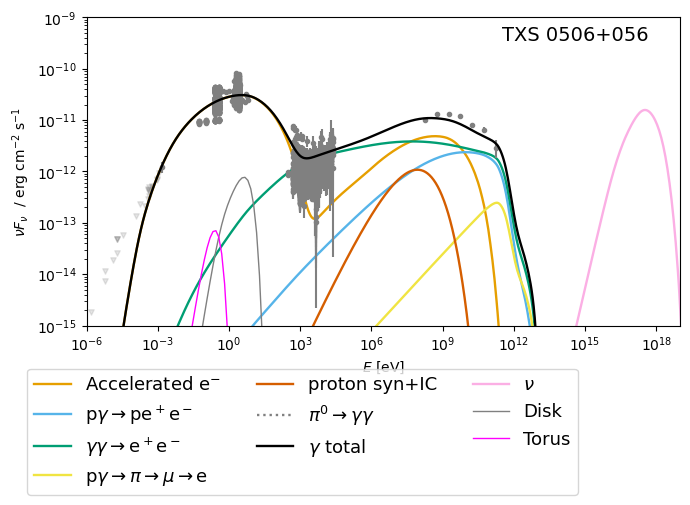

In [243]:

# Import EBL attenuation cutoff from gammapy
# ##########################################

# Download data

import requests
url = 'https://github.com/gammapy/gammapy-extra/raw/master/datasets/ebl/ebl_dominguez11.fits.gz'

os.makedirs('data/ebl', exist_ok=True)
local_filename = 'data/ebl/ebl_dominguez11.fits.gz'

response = requests.get(url)
with open(local_filename, 'wb') as f:
    f.write(response.content)

print(f"EBL data downloaded from gammapy-extras and saved as {local_filename}")

# Implement Spectral attenuation model

from gammapy.modeling.models import (
    EBLAbsorptionNormSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)
os.environ["GAMMAPY_DATA"] = "./data/"
dominguez = EBLAbsorptionNormSpectralModel.read_builtin("dominguez", redshift=0.)


# Conversion factors
# ##################

z = 0.33

# Jet frame -> obs. frame
energy_conversion = lorentz / (1 + z) 

# erg/cm3, source frame -> erg/cm2/s, obs. frame
lum_dist = cosmo.luminosity_distance(z).cgs.value
density_to_lum = 4 * np.pi * (3e10 * am3.get_escape_timescale()) ** 2 * const.c.cgs.value
lum_to_flux = 1./(4 * np.pi * lum_dist ** 2)
spectrum_conversion = density_to_lum * lum_to_flux * lorentz ** 4

# Energy arrays in source frame
egrid_pho = am3.get_egrid_photons()
egrid_nu = am3.get_egrid_neutrinos()

# Energy arrays in observer's frame
egrid_pho_obs = egrid_pho * energy_conversion
egrid_nu_obs = egrid_nu * energy_conversion

# Implement attenuation
atten = dominguez.evaluate(egrid_pho_obs * u.eV, 0.19, 1.0) 


# Get individual SED components from AM3
# ######################################

all_nu = am3.get_neutrinos() * egrid_nu * u.eV.to(u.erg) * spectrum_conversion
external_pho = am3.get_injection_rate_photons() * am3.get_escape_timescale() *  egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
injected = am3.get_photons_injected_electrons_syn_compton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
annihil = am3.get_photons_annihilation_pairs_syn_compton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
bheitler = am3.get_photons_bethe_heitler_pairs_syn_compton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
pgamma = am3.get_photons_photo_pion_pairs_syn_compton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
pi0decay = am3.get_photons_pi0_decay() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
proton_syn_ic = am3.get_photons_protons_syn_compton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
pp_pions = am3.get_photons_pi0_decay_proton_proton() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten
all_gammas = am3.get_photons_except_injected() * egrid_pho * u.eV.to(u.erg) * spectrum_conversion * atten


# Create plot
# ###########

_ = plt.figure(figsize=(7,6))

mycolors = np.array([np.array([230,159,  0.]),
                     np.array([ 86,180,233.]),
                     np.array([  0,158,115.]),
                     np.array([240,228, 66.]),
                     np.array([  0,114,178.]),
                     np.array([213, 94,  0.]),
                     np.array([201,121,176.])])
mycolors *= 1./255

# Plot components
plt.loglog(egrid_pho_obs, injected,
            c=mycolors[0],
            lw=1.7,
            label=r'Accelerated e$^{-}$')

plt.loglog(egrid_pho_obs, bheitler,
            c=mycolors[1],
            lw=1.7,
            label=r'p$\gamma\rightarrow$pe$^+$e$^-$')

plt.loglog(egrid_pho_obs, annihil,
            c=mycolors[2],
            lw=1.7,
            label=r'$\gamma\gamma\rightarrow$e$^+$e$^-$')


plt.loglog(egrid_pho_obs, pgamma,
            c=mycolors[3],
            lw=1.7,
            label=r'p$\gamma\rightarrow\pi\rightarrow\mu\rightarrow$e')

plt.loglog(egrid_pho_obs, proton_syn_ic,
            c=mycolors[5],
            lw=1.7,
            label='proton syn+IC')

# Gamma rays from pi zeros are attenuated in EBL interactions
plt.loglog(egrid_pho_obs, pi0decay,
            c='gray', 
            ls=':',lw=1.7,
            label=r'$\pi^0\rightarrow\gamma\gamma$')

plt.loglog(egrid_pho_obs, all_gammas,
            c='k',lw=1.7,zorder=500,
            label=r'$\gamma$ total')

# Plot all-flavor neutrino spectrum
plt.loglog(egrid_nu_obs, all_nu, label=r'$\nu$',
            lw=1.7, color=sns.color_palette("colorblind",12)[6])

# Plot thermal emission

ethermal = np.logspace(-3,3,50)
eobs = ethermal / (1 + z)
disk = ShakuraFlux(ethermal * u.eV, 
                    DISK_LUM,
                    black_hole_mass
                    ) * lum_to_flux

torus = PlanckDistribution(ethermal * u.eV,
                            torus_temperature,
                            DISK_LUM * torus_covering * u.erg/u.s
                            ) * lum_to_flux

plt.loglog(eobs, disk, color='gray',lw=1.0,label='Disk')
plt.loglog(eobs, torus, color='magenta',lw=1.0,label='Torus')

plt.xlabel(r"$E$ [eV]")
plt.ylabel(r"$\nu F_\nu$  / erg cm$^{-2}$ s$^{-1}$")
plt.axis([1e-6,1e19,1e-15,1e-9])

plt.annotate("TXS 0506+056", 
(5e17,3.5e-10), 
fontsize=14, 
horizontalalignment='right')

plt.legend(loc=(-0.1,-0.55), fontsize=13,frameon=1,ncol=3)

plt.scatter(data_x[~is_uplim],data_y[~is_uplim], marker='.',c='gray',s=10,alpha=1.0)
plt.errorbar(data_x[~is_uplim],data_y[~is_uplim], (data_errlo[~is_uplim],data_errup[~is_uplim]), marker='.',c='gray',alpha=1.0,ls='none')
plt.scatter(data_x[is_uplim],data_y[is_uplim], marker='v',c='gray',alpha=0.2,s=15)
# plt.scatter(10**binned_x[~binned_isuplim], 10**binned_y[~binned_isuplim], marker='s',alpha=0.8,zorder=500,color='r')
# plt.scatter(10**binned_x[binned_isuplim], 10**binned_y[binned_isuplim], marker='v',alpha=0.8,zorder=500,color='r')
# # plt.errorbar(10**binned_x[~binned_isuplim], 10**binned_y[~binned_isuplim], 10**binned_err[~binned_isuplim], alpha=1.0,ls='none',color='r',zorder=1000)

# plt.savefig("blazar_photon_densities.pdf",bbox_inches='tight')


plt.tight_layout()
    
    
plt.show()
